In [15]:
!pip install scanpy
!pip install anndata
!pip install igraph
!pip install celltypist
!pip install decoupler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 67.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.1
    Uninstalling scikit-learn-1.5.1:
      Successfully uninstalled scikit-learn-1.5.1
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.2
    Uninstalling statsmodels-0.14.2:
      Successfully uninstalled statsmodels-0.14.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19877 sha256=90b36a5da52c833dcd55f8f138faf68f431ce6dee32c05ce39be622f2fc62

In [88]:
import scanpy as sc
import anndata as ad

In [18]:
!wget https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad

--2025-11-11 22:25:02--  https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 354509549 (338M) [application/octet-stream]
Saving to: ‘bone_marrow.h5ad’

bone_marrow.h5ad    100%[===================>] 338.09M  51.9MB/s    in 6.5s    

2025-11-11 22:25:09 (52.0 MB/s) - ‘bone_marrow.h5ad’ saved [354509549/354509549]



In [21]:
bone_marrow_adata= sc.read_h5ad("/Users/kashish/Downloads/bone_marrow (2).h5ad")
print (bone_marrow_adata)

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


In [22]:
bone_marrow_adata.shape

(14783, 17374)

In [23]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding


In [24]:
bone_marrow_adata.obs.head

<bound method NDFrame.head of                        disease stage                    treatment timepoint  \
index                                                                         
Guo-AAACCTGAGAGCTTCT-2        severe  400 mg Tocilizumab at day 1     day 1   
Guo-AAACCTGAGAGGTTGC-7     remission  400 mg Tocilizumab at day 1     day 7   
Guo-AAACCTGAGATACACA-3     remission  400 mg Tocilizumab at day 1     day 5   
Guo-AAACCTGAGCGATTCT-1        severe  400 mg Tocilizumab at day 1     day 1   
Guo-AAACCTGAGTGAAGAG-3     remission  400 mg Tocilizumab at day 1     day 5   
...                              ...                          ...       ...   
Guo-TTTGTCAGTTTCGCTC-4     remission  400 mg Tocilizumab at day 1     day 5   
Guo-TTTGTCATCAGAGACG-7     remission  400 mg Tocilizumab at day 1     day 7   
Guo-TTTGTCATCAGATAAG-4     remission  400 mg Tocilizumab at day 1     day 5   
Guo-TTTGTCATCTCCTATA-4     remission  400 mg Tocilizumab at day 1     day 5   
Guo-TTTGTCATCTGCGGCA-2

In [25]:
bone_marrow_adata.to_df()

,ENSG00000161920,ENSG00000122335,ENSG00000175548,ENSG00000100330,ENSG00000176340,ENSG00000179846,ENSG00000204860,ENSG00000172260,ENSG00000141424,ENSG00000164512,...,ENSG00000164114,ENSG00000151702,ENSG00000224578,ENSG00000138756,ENSG00000111052,ENSG00000176946,ENSG00000150456,ENSG00000284934,ENSG00000261842,ENSG00000260456
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.0,0.000000,0.0,0.0,9.436466,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,8.817776,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,0.0,8.651494,0.0,0.0,8.651494,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,0.0,0.000000,0.0,0.0,8.858533,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTTCGCTC-4,0.0,0.000000,0.0,0.0,8.389465,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGAGACG-7,0.0,0.000000,0.0,0.0,9.931639,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGATAAG-4,0.0,0.000000,0.0,0.0,10.009642,0.0,0.0,0.0,0.000000,0.0,...,0.0,9.01104,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
bone_marrow_adata.var_names_make_unique()
bone_marrow_adata.obs_names_make_unique()

In [29]:
bone_marrow_adata.var["MT"]= bone_marrow_adata.var_names.str.startswith("MT-")
bone_marrow_adata.var["RIBO"]= bone_marrow_adata.var_names.str.startswith("RPS", "RPL")
bone_marrow_adata.var["HB"]= bone_marrow_adata.var_names.str.startswith("^HB[^(P)]")
                                                                

In [30]:
mt_genes= bone_marrow_adata.var[bone_marrow_adata.var["MT"]]

In [38]:
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, qc_vars=["MT","RIBO","HB"]
)

(                        n_genes_by_counts  log1p_n_genes_by_counts  \
 index                                                                
 Guo-AAACCTGAGAGCTTCT-2               1407                 7.249926   
 Guo-AAACCTGAGAGGTTGC-7                903                 6.806829   
 Guo-AAACCTGAGATACACA-3                877                 6.777647   
 Guo-AAACCTGAGCGATTCT-1                933                 6.839476   
 Guo-AAACCTGAGTGAAGAG-3                467                 6.148468   
 ...                                   ...                      ...   
 Guo-TTTGTCAGTTTCGCTC-4               1101                 7.004882   
 Guo-TTTGTCATCAGAGACG-7               2246                 7.717351   
 Guo-TTTGTCATCAGATAAG-4                694                 6.543912   
 Guo-TTTGTCATCTCCTATA-4                832                 6.725034   
 Guo-TTTGTCATCTGCGGCA-2               1156                 7.053586   
 
                         total_counts  log1p_total_counts  \
 index        

In [32]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding,False,False,False
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding,False,False,False
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding,False,False,False
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding,False,False,False
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding,False,False,False


In [33]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,is_primary_data,suspension_type,tissue_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,2P)e%zgsv_
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,78-year-old stage,Lv&N1yD6*0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,DZ>`^5OH2o
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,J4$QmqEgvX
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,Y&7u#&E`-T


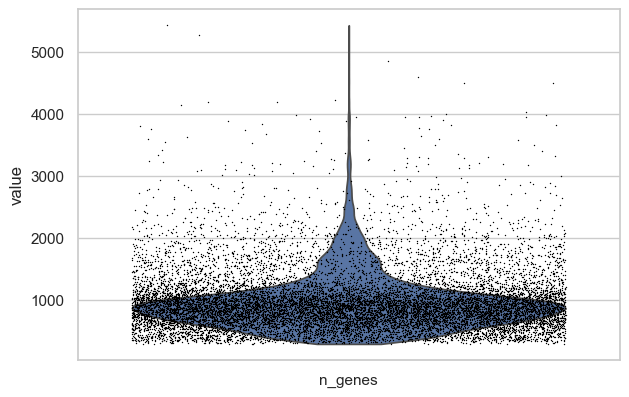

In [35]:
sc.pl.violin(
    bone_marrow_adata,
    ["n_genes"],
    jitter=0.4,
    multi_panel=False,
)

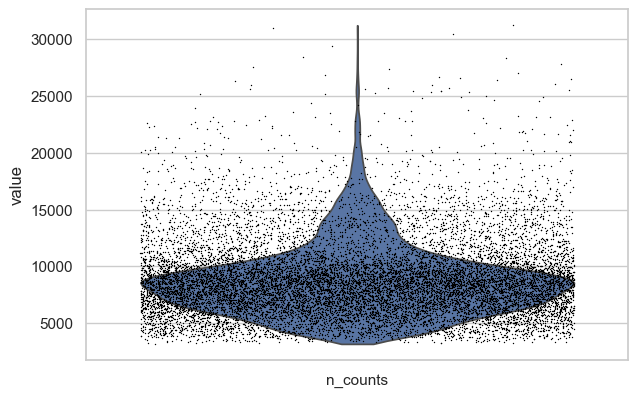

In [36]:
sc.pl.violin(
    bone_marrow_adata,
    ["n_counts"],
    jitter=0.4,
    multi_panel=False,
)

In [41]:
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    inplace=True, 
    percent_top=None, 
    log1p=False
    # Removed 'n_genes_by_counts=True' as it's not a valid parameter
    # n_genes_by_counts is a metric that gets calculated automatically
)

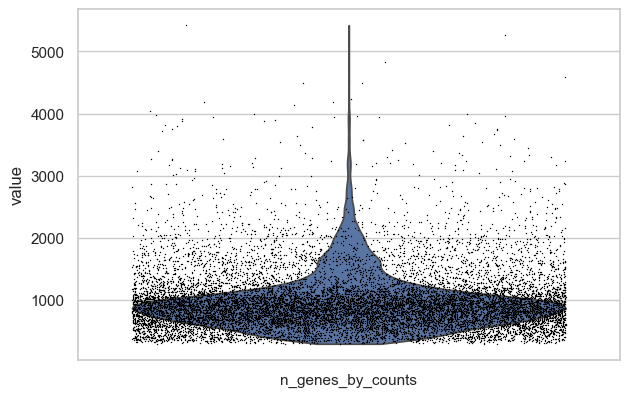

In [42]:
sc.pl.violin(
    bone_marrow_adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=False,
)

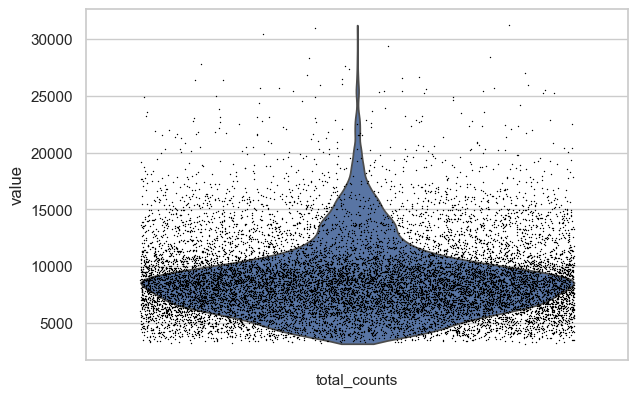

In [43]:
sc.pl.violin(
    bone_marrow_adata,
    ["total_counts"],
    jitter=0.4,
    multi_panel=False,
)

In [45]:
bone_marrow_adata.var['mt'] = bone_marrow_adata.var_names.str.startswith(('MT-', 'mt-'))
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)


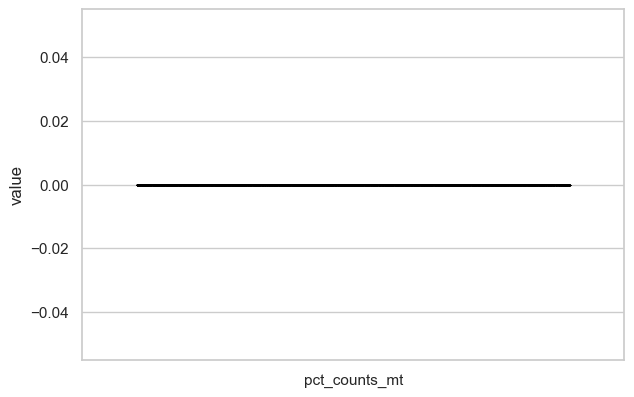

In [46]:
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_mt"],  # Note: the column is typically named 'pct_counts_mt' (lowercase)
    jitter=0.4,
    multi_panel=False,
)

In [48]:
bone_marrow_adata.var["RIBO"]= bone_marrow_adata.var_names.str.startswith("RPS", "RPL")
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    qc_vars=["RIBO"], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

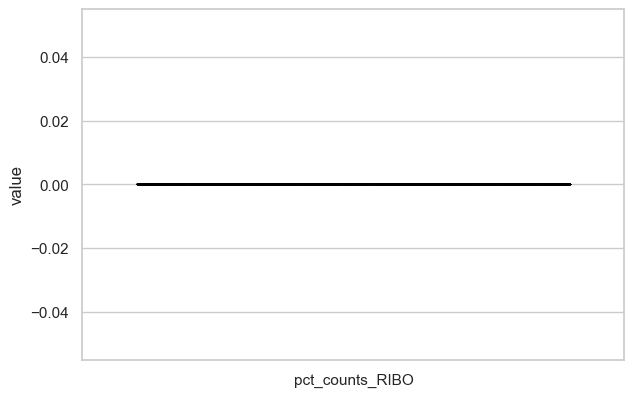

In [49]:
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_RIBO"],  # Note: the column is typically named 'pct_counts_mt' (lowercase)
    jitter=0.4,
    multi_panel=False,
)

In [56]:
bone_marrow_adata.var['HB'] = bone_marrow_adata.var_names.str.startswith(('MT-', 'mt-'))
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    qc_vars=['HB'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)


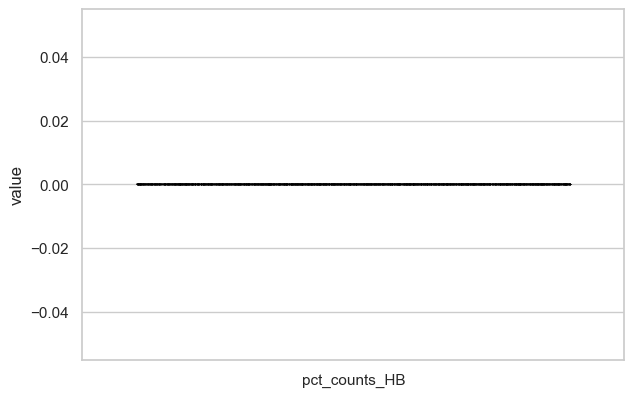

In [57]:
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_HB"],  # Note: the column is typically named 'pct_counts_mt' (lowercase)
    jitter=0.4,
    multi_panel=False,
)

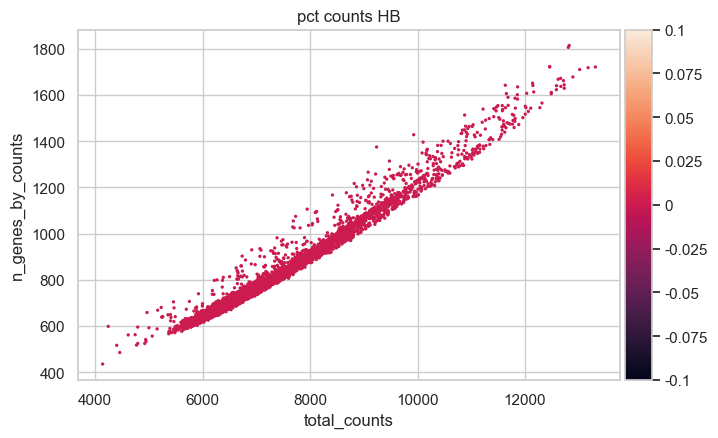

In [58]:
sc.pl.scatter(bone_marrow_adata, 
              x="total_counts",    # Make sure this column exists in .obs
              y="n_genes_by_counts", # Make sure this column exists in .obs
              color="pct_counts_HB") # Make sure this column exists in .obs



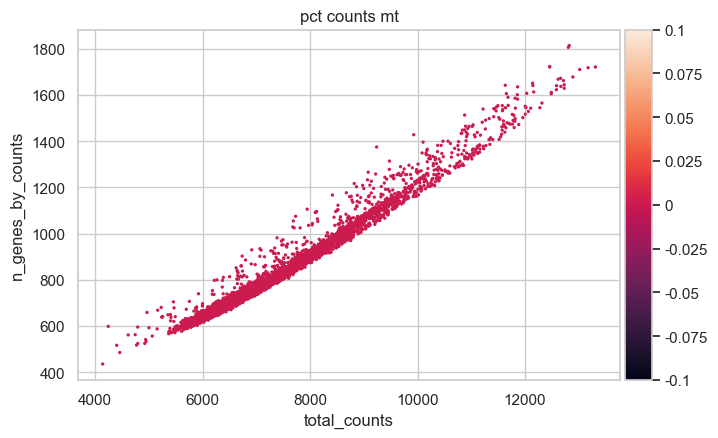

In [59]:
sc.pl.scatter(bone_marrow_adata, 
              x="total_counts",    # Make sure this column exists in .obs
              y="n_genes_by_counts", # Make sure this column exists in .obs
              color="pct_counts_mt") # Make sure this column exists in .obs



In [60]:
bone_marrow_adata= bone_marrow_adata[
bone_marrow_adata.obs['pct_counts_RIBO']<10,
:
]

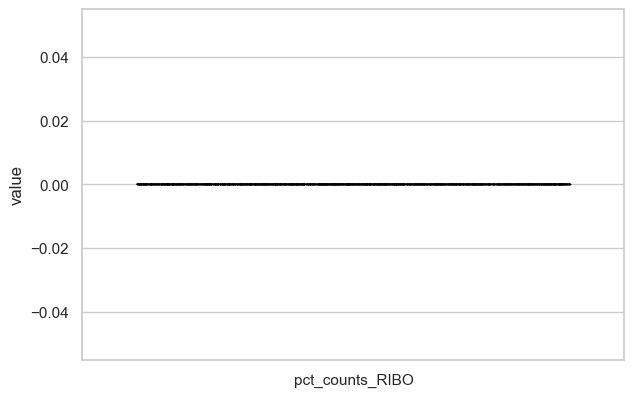

In [61]:
sc.pl.violin(bone_marrow_adata,
            ["pct_counts_RIBO"],
            jitter=0.4,
            multi_panel=False,
            )

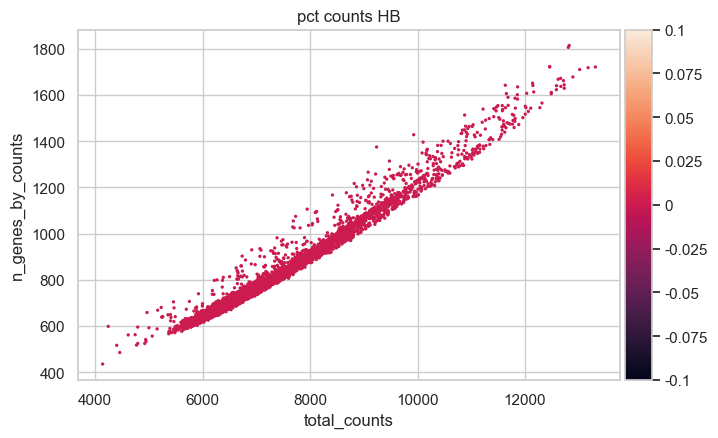

In [64]:
sc.pl.scatter(bone_marrow_adata, 
              x="total_counts",
              y="n_genes_by_counts", 
              color="pct_counts_HB" 
             )

In [70]:
bone_marrow_adata= bone_marrow_adata[bone_marrow_adata.obs['pct_counts_RIBO']<10,
]

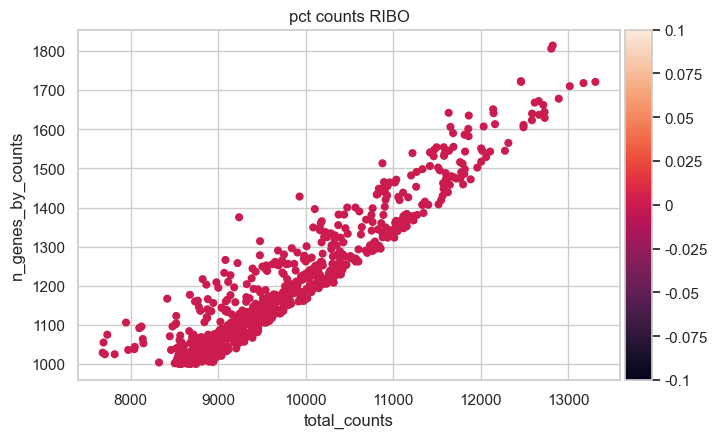

In [71]:
sc.pl.scatter(bone_marrow_adata,"total_counts","n_genes_by_counts", color="pct_counts_RIBO" )

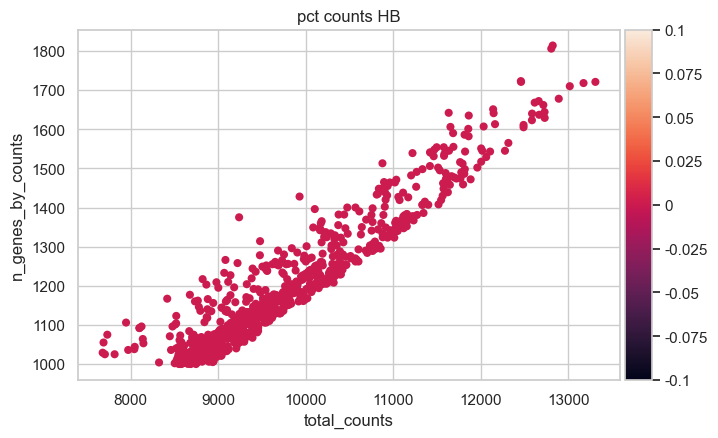

In [72]:
sc.pl.scatter(bone_marrow_adata,"total_counts","n_genes_by_counts", color="pct_counts_HB" )

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


/opt/anaconda3/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
python(82097) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/var/folders/dz/k0w43hv15fl0c_xmfvxrlb580000gn/T/ipykernel_4273/74712296.py:78: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(bone_marrow_adata, resolution=1.0)


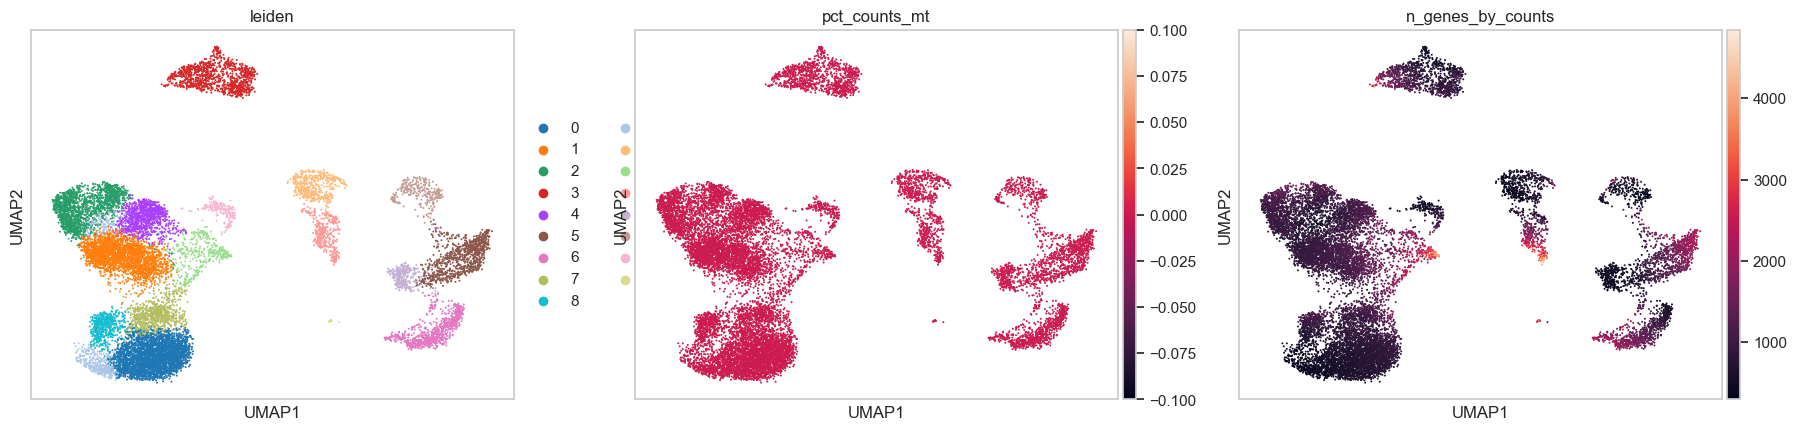

In [85]:
bone_marrow_adata= sc.read_h5ad("/Users/kashish/Downloads/bone_marrow (2).h5ad")
print (bone_marrow_adata)
import scanpy as sc
import numpy as np
from scipy.sparse import issparse

# ---------------------------
# 1. BASIC QC SETUP
# ---------------------------

# 1.1 Identify mitochondrial genes
bone_marrow_adata.var['mt'] = bone_marrow_adata.var_names.str.upper().str.startswith('MT-')

# 1.2 Compute QC metrics
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

# ---------------------------
# 2. FILTER LOW-QUALITY CELLS & GENES
# ---------------------------

# 2.1 Remove cells with ZERO counts (your previous error source)
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['total_counts'] > 0].copy()

# 2.2 Reasonable QC thresholds  
# (safe values; will NOT delete everything)
sc.pp.filter_cells(bone_marrow_adata, min_genes=200)    # cells with ≥200 genes
sc.pp.filter_genes(bone_marrow_adata, min_cells=3)      # genes in ≥3 cells

# Optional: filter based on mitochondrial % and count outliers
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['pct_counts_mt'] < 20].copy()
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['total_counts'] < 30000].copy()
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['n_genes_by_counts'] < 7000].copy()

# ---------------------------
# 3. NORMALIZATION & HVG
# ---------------------------

# 3.1 Normalize counts per cell
sc.pp.normalize_total(bone_marrow_adata, target_sum=1e4)

# 3.2 Log transform
sc.pp.log1p(bone_marrow_adata)

# 3.3 Identify highly variable genes
sc.pp.highly_variable_genes(
    bone_marrow_adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

bone_marrow_adata = bone_marrow_adata[:, bone_marrow_adata.var['highly_variable']].copy()

# ---------------------------
# 4. SCALE + PCA
# ---------------------------

sc.pp.scale(bone_marrow_adata, max_value=10)
sc.tl.pca(bone_marrow_adata, svd_solver='arpack')

# ---------------------------
# 5. NEIGHBORS + UMAP
# ---------------------------

sc.pp.neighbors(bone_marrow_adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(bone_marrow_adata)

# ---------------------------
# 6. CLUSTERING
# ---------------------------

sc.tl.leiden(bone_marrow_adata, resolution=1.0)

# ---------------------------
# 7. PLOTTING
# ---------------------------

sc.pl.umap(bone_marrow_adata, color=['leiden', 'pct_counts_mt', 'n_genes_by_counts'])


In [86]:
print(bone_marrow_adata.var_names[:20])


Index(['ENSG00000122335', 'ENSG00000175548', 'ENSG00000204860',
       'ENSG00000164512', 'ENSG00000162623', 'ENSG00000134321',
       'ENSG00000166250', 'ENSG00000157388', 'ENSG00000148498',
       'ENSG00000162894', 'ENSG00000196912', 'ENSG00000185522',
       'ENSG00000170365', 'ENSG00000163131', 'ENSG00000124783',
       'ENSG00000152527', 'ENSG00000187837', 'ENSG00000181896',
       'ENSG00000121766', 'ENSG00000206562'],
      dtype='object')


In [91]:
marker_genes = {
    "HSC/Progenitor": ["CD34", "CD38", "KIT", "GATA2"],
    "T_cells": ["CD3D", "CD3E", "CD2", "TRAC"],
    "B_cells": ["CD19", "MS4A1", "CD79A"],
    "NK_cells": ["NCAM1", "NKG7", "GNLY"],
    "Monocytes": ["CD14", "LYZ", "FCGR3A"],
    "Dendritic": ["ITGAX", "CLEC9A", "CD1C"],
    "Megakaryocytes": ["PF4", "ITGA2B", "GP1BA"],
    "Erythroid": ["HBB", "HBA1", "HBA2"],
    "Mesenchymal": ["COL1A1", "PDGFRA", "LUM"],
    "Endothelial": ["PECAM1", "VWF", "CDH5"]
}

for ct, genes in marker_genes.items():
    present = [g for g in genes if g in bone_marrow_adata.var_names]
    print(f"{ct}: {len(present)} / {len(genes)} markers found -> {present}")


HSC/Progenitor: 0 / 4 markers found -> []
T_cells: 0 / 4 markers found -> []
B_cells: 0 / 3 markers found -> []
NK_cells: 0 / 3 markers found -> []
Monocytes: 0 / 3 markers found -> []
Dendritic: 0 / 3 markers found -> []
Megakaryocytes: 0 / 3 markers found -> []
Erythroid: 0 / 3 markers found -> []
Mesenchymal: 0 / 3 markers found -> []
Endothelial: 0 / 3 markers found -> []
